correlation

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# Read ratings.csv for all raters
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
    # '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/test_fetalqc/ratings.csv',
    # Add paths for other rater files as needed
]

# Aggregate data for all raters
raters_data = []
for file in raters_files:
    df = pd.read_csv(file)
    raters_data.append(df)

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']
ALPHA = 0.05

# Compute pairwise correlations for numeric metrics
for metric_name in metrics_names:
    metrics = [rater[metric_name].to_numpy() for rater in raters_data]
    
    print(f"\nMetric: {metric_name}")
    for i in range(len(metrics)):
        for j in range(i + 1, len(metrics)):
            r_squared, p_value = stats.pearsonr(metrics[i], metrics[j])
            print(f"Rater {i + 1} vs Rater {j + 1}: r^2 = {r_squared:.4}, p-value = {p_value:.4}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = 0
for i in range(total_cases):
    values = [eyes_open[i] for eyes_open in eyes_open_data]
    if all(v == values[0] for v in values):  # Check if all raters agree
        agreement_count += 1

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")


Metric: rating
Rater 1 vs Rater 2: r^2 = 0.8007, p-value = 2.487e-16

Metric: rating1
Rater 1 vs Rater 2: r^2 = 0.7956, p-value = 5.248e-16

Metric: rating2
Rater 1 vs Rater 2: r^2 = 0.7408, p-value = 5.149e-13

Metric: blur
Rater 1 vs Rater 2: r^2 = 0.3139, p-value = 0.009142

Metric: noise
Rater 1 vs Rater 2: r^2 = 0.4416, p-value = 0.0001634

Metric: motion
Rater 1 vs Rater 2: r^2 = 0.4222, p-value = 0.0003359

Metric: bgair
Rater 1 vs Rater 2: r^2 = 0.1971, p-value = 0.1071

Eyes open agreement: 86.76% of cases


pie charts

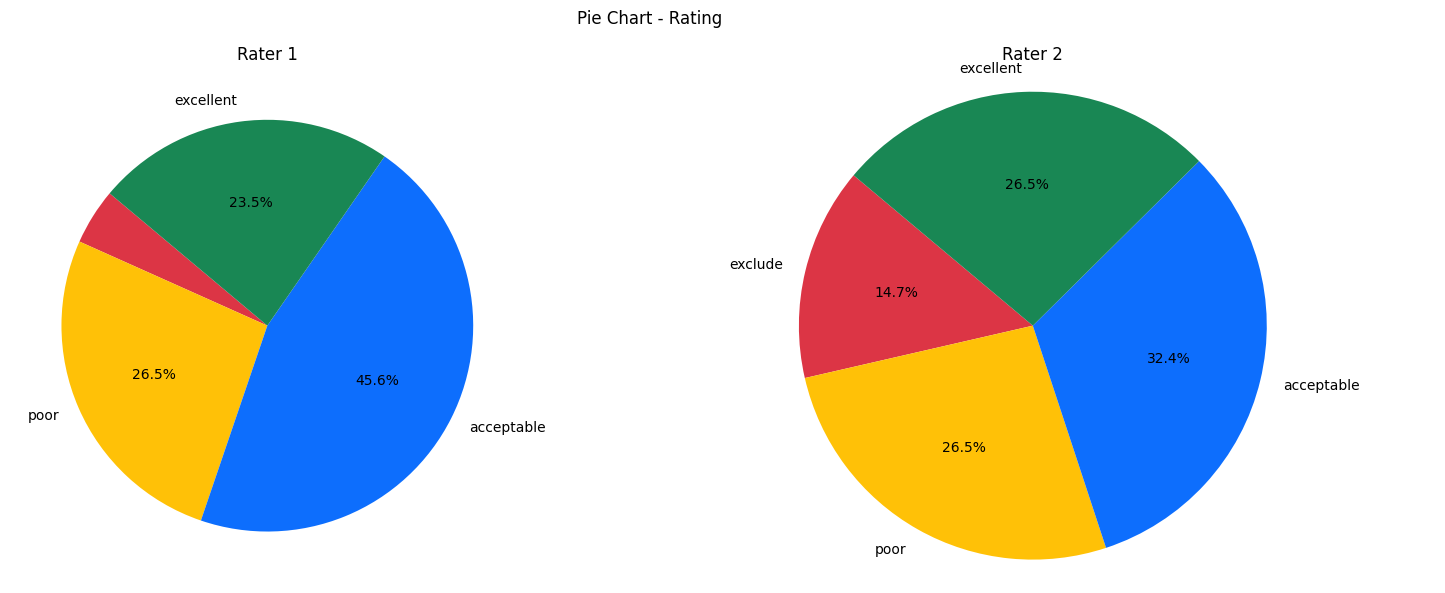

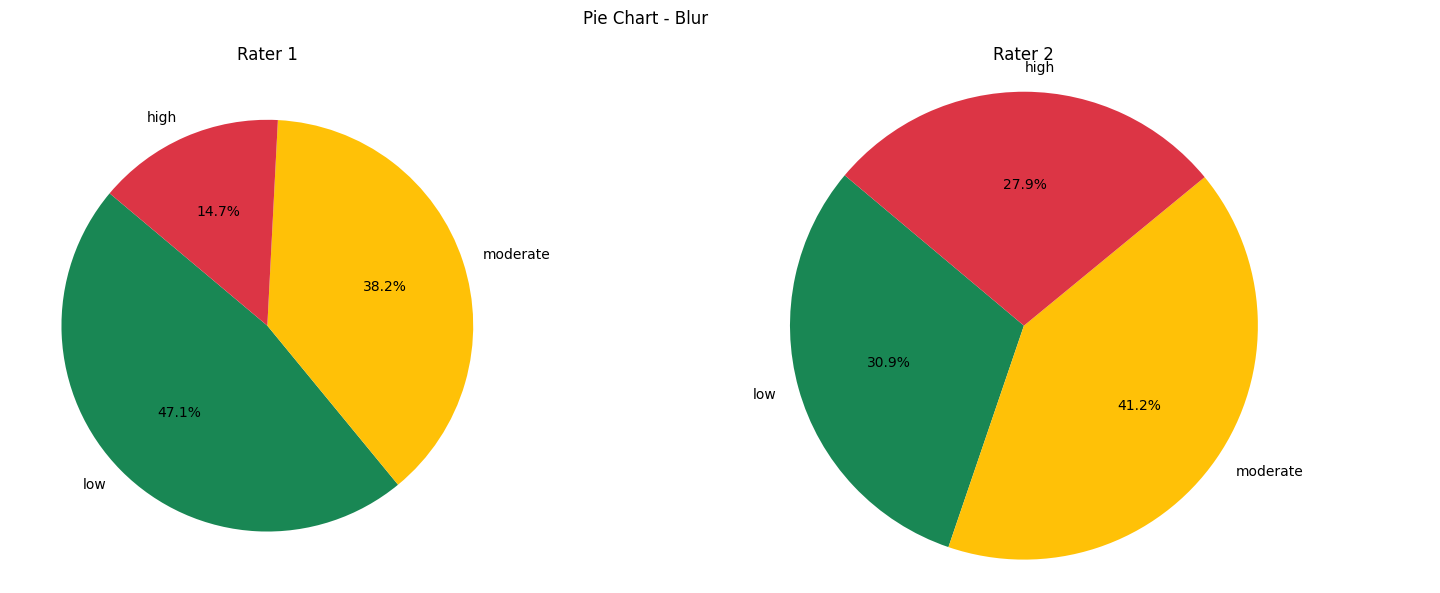

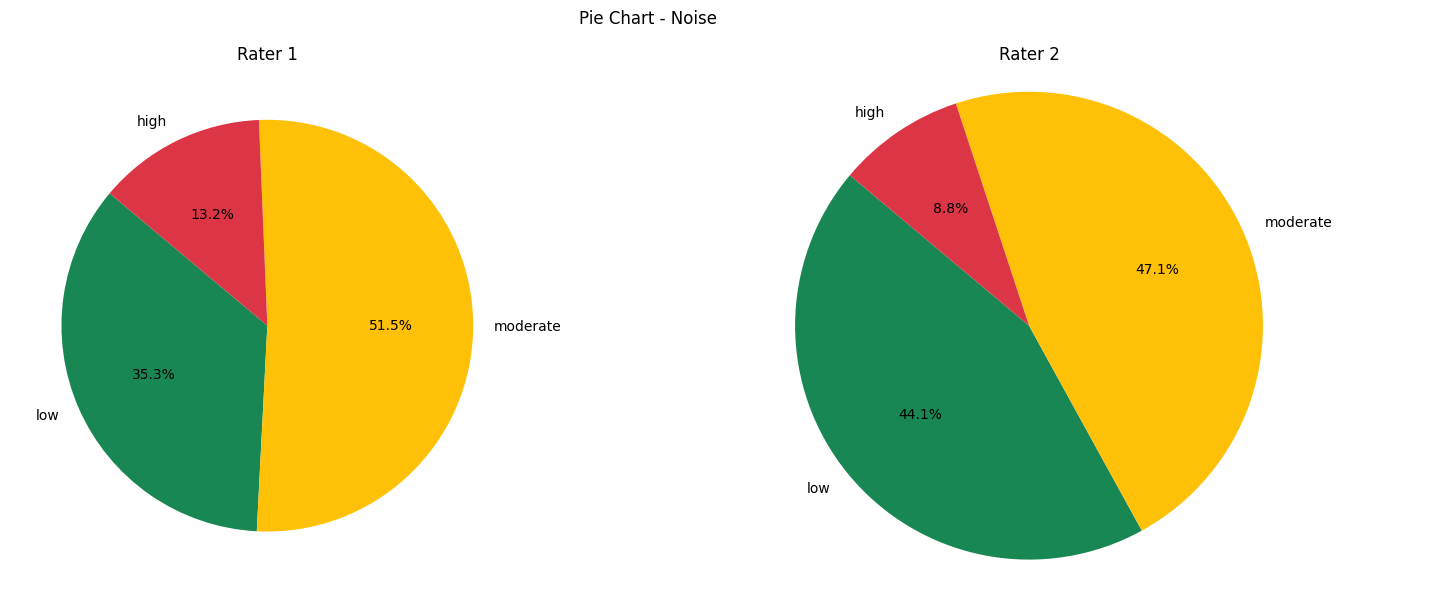

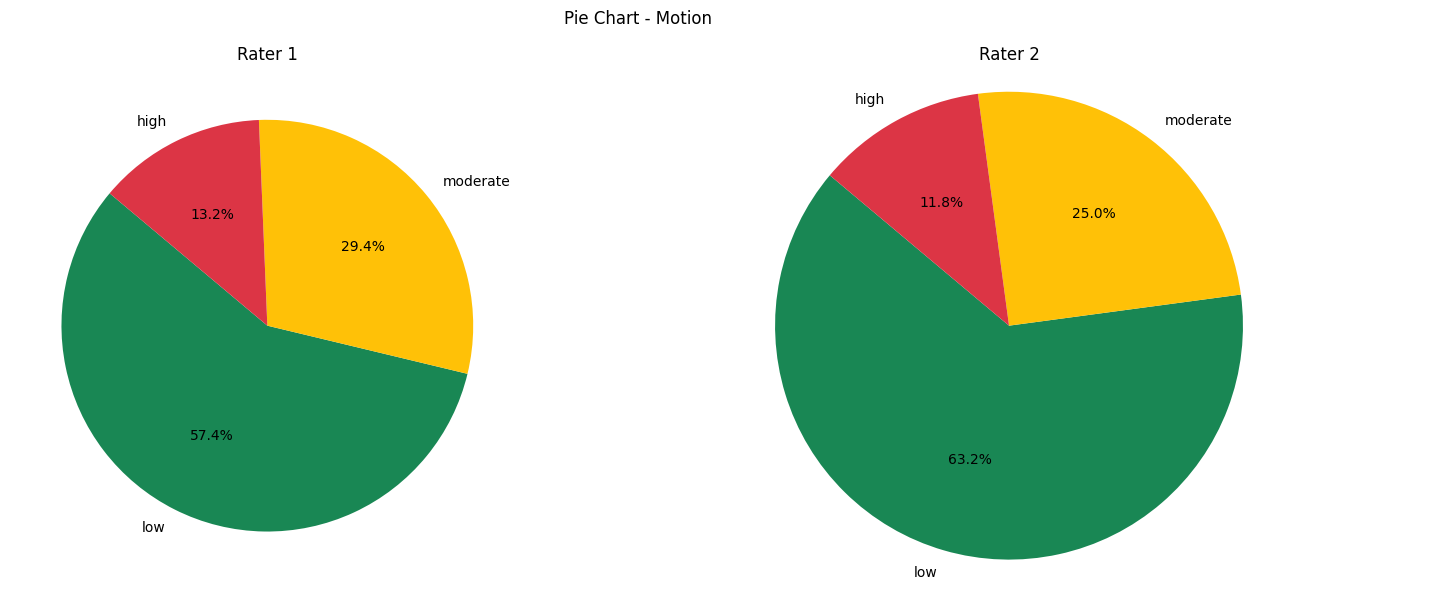

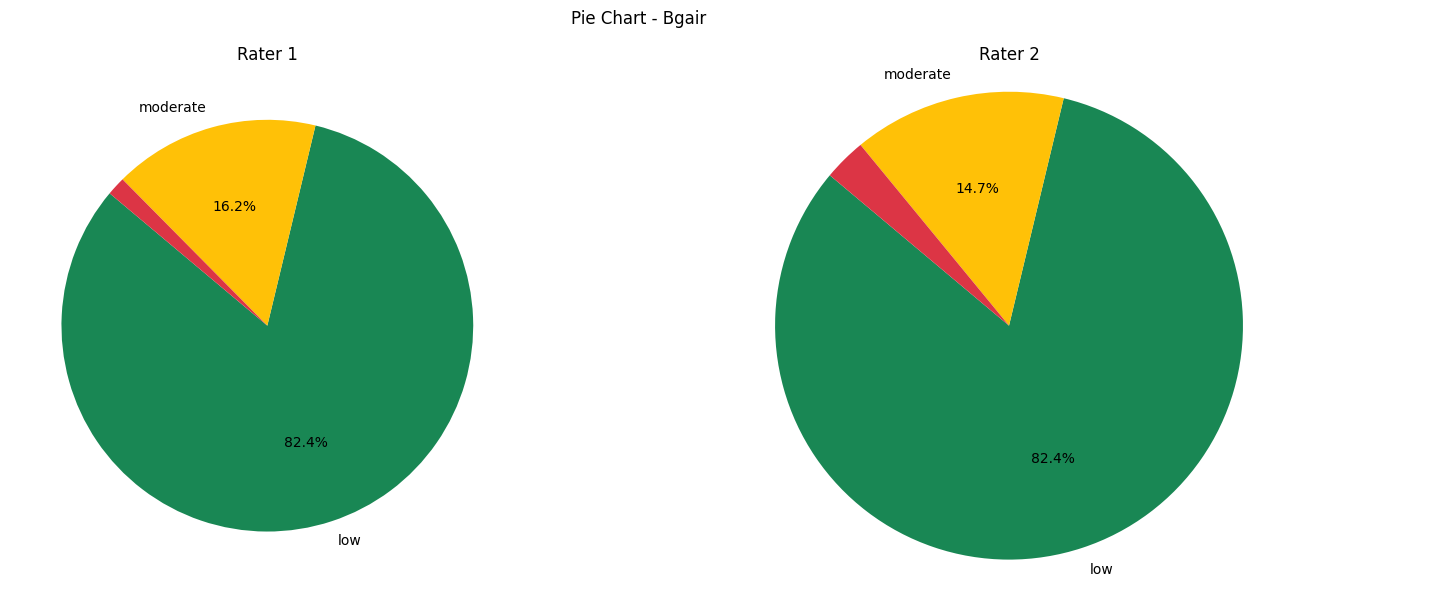

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Raters' data files
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
    # '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/test_fetalqc/ratings.csv',
    # Add more paths if necessary
]

# Define metrics and categories
metrics = {
    'rating_text': ['exclude', 'poor', 'acceptable', 'excellent'],
    'blur_text': ['low', 'moderate', 'high'],
    'noise_text': ['low', 'moderate', 'high'],
    'motion_text': ['low', 'moderate', 'high'],
    'bgair_text': ['low', 'moderate', 'high']
}

# Colors for 4 and 3 categories
colors_map = {
    4: ['#dc3545', '#ffc107', '#0d6efd', '#198754'],
    3: ['#198754', '#ffc107', '#dc3545']
}

# Threshold below which labels are not displayed
LABEL_THRESHOLD = 5  # Percent

# Load data
raters_data = [pd.read_csv(file) for file in raters_files]

# Generate pie charts for each metric
for metric_name, categories in metrics.items():
    num_categories = len(categories)
    colors = colors_map[num_categories]
    
    fig, ax = plt.subplots(1, len(raters_data), figsize=(8 * len(raters_data), 6))
    if len(raters_data) == 1:  # Handle single subplot case
        ax = [ax]
    
    for i, rater_data in enumerate(raters_data):
        counts = [rater_data[metric_name].to_list().count(cat) for cat in categories]
        total = sum(counts)
        percentages = [(count / total) * 100 for count in counts]
        
        # Filter labels below threshold
        filtered_labels = [
            f"{categories[idx]}" if percentages[idx] >= LABEL_THRESHOLD else ""
            for idx in range(len(categories))
        ]
        
        ax[i].pie(
            counts,
            labels=filtered_labels,
            autopct=lambda p: f'{p:.1f}%' if p >= LABEL_THRESHOLD else '',  # Hide small slices
            startangle=140,
            colors=colors
        )
        ax[i].set_title(f'Rater {i + 1}')
    
    # Add title and formatting
    fig.suptitle(f'Pie Chart - {metric_name.replace("_text", "").capitalize()}')
    fig.tight_layout()
    fig.set_facecolor('white')
    plt.axis('equal')
    plt.show()


scatter plots - ggplot

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load rater data
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
]

raters_data = [pd.read_csv(file) for file in raters_files]

# Define metrics
metrics = {
    'Rating': lambda df: np.mean([df['rating1'].to_numpy(), df['rating2'].to_numpy()], axis=0),
    'Blur': lambda df: df['blur'].to_numpy(),
    'Noise': lambda df: df['noise'].to_numpy(),
    'Motion': lambda df: df['motion'].to_numpy(),
    'BgAir': lambda df: df['bgair'].to_numpy(),
    'Eyes Closed': lambda df: np.where(df['artifacts'].to_numpy() == "['eyes-open']", 1, 0),
}

# Function to create interactive scatter plots
def plot_metric_interactive(metric_name, metric_funcs, raters_data):
    all_data = []
    
    for rater_index, df in enumerate(raters_data):
        metric_data = metric_funcs[metric_name](df)
        subjects = np.arange(len(metric_data))
        
        temp_df = pd.DataFrame({
            'Subject Index': subjects,
            metric_name: metric_data,
            'Rater': f'Rater {rater_index + 1}'
        })
        
        all_data.append(temp_df)
    
    merged_data = pd.concat(all_data, ignore_index=True)
    
    fig = px.scatter(
        merged_data, 
        x='Subject Index', 
        y=metric_name, 
        color='Rater', 
        hover_data={'Subject Index': True, metric_name: True, 'Rater': True},
        title=f"{metric_name} Comparison Across Raters",
        template="plotly_white"
    )
    
    fig.show()

# Generate interactive plots for all metrics
for metric_name in metrics.keys():
    plot_metric_interactive(metric_name, metrics, raters_data)
